# Problem Statement

ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

<b>EXERCISE</b>: Before proceeding further, take a moment to think about how can approach this problem. List five or more ideas that come to your mind below:

* Understand the dataset and define input features and target variable (charges)
* Perform data cleaning and preprocessing (handle missing values, encode categories)
* Explore the data using visualization and statistics (EDA)
* Select and train an interpretable model (e.g., linear regression)
* Evaluate the model and explain predictions for new customers

In [1]:
file_path = "./data/medical_data.csv"

In [2]:
import pandas as pd

In [3]:
medical_df = pd.read_csv(file_path)

In [4]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The dataset contains 1338 rows and 7 columns. Each row of the dataset contains information about one customer

Our object is to find a way to estimate the value in the "charges" column using the valuese in the other columns. If we can do so for the historical data, then we should be able to estimate charages for new customers too, simply by asking for information like their age, sex, BMI, no. of children, smoking habits and region.

let's check the data type for each column.

In [5]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The ranges of values in the numerical columns seem reasonable too. So we may not have to do much data cleaning or correction. The "charges" column seems to be significantly skewed however, as the median (50 perrcentile) is much lower that the maximum value.

# Exploratory Analysis and Visualization

Let's explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "charges" and other columns.

In [7]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

The following settings will improve the default style and font sizes for our charts

In [8]:
sns.set_style('darkgrid')

In [9]:
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Age

Age is a numeric column. The minimum age in the dataset is 18 and the aximum age is 64. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot. We'll use plotly to make the chart interactive, but you can create similar charts using Seaborn.

In [10]:
 medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

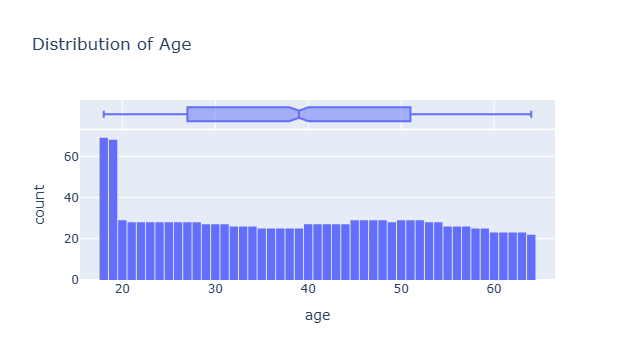

In [11]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the datset is almost uniform, with 20-30 custormers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any given age(between 18 & 64) in the USA.

## Body Mass Index (BMI)

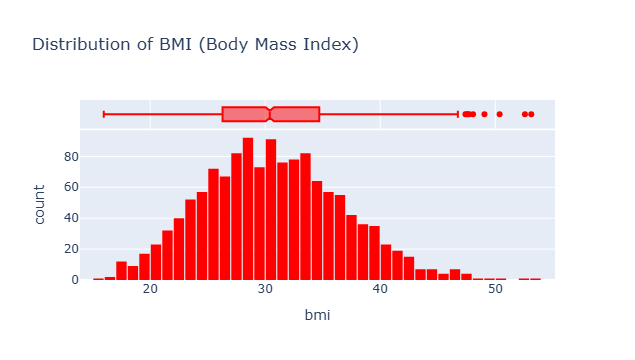

In [12]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

## Charges

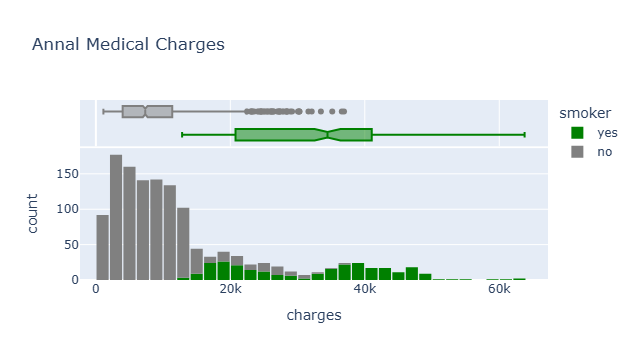

In [13]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annal Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

* For most customers, the annual medical charges are under $10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follow a "power law"

* There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is `$7300`, the emedian for smokers is close to `$35,000`

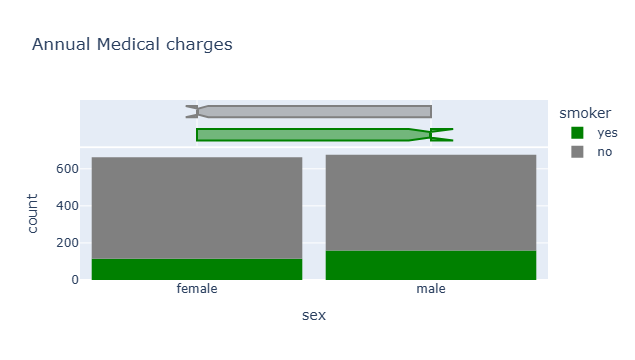

In [15]:
fig = px.histogram(medical_df,
                   x='sex',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical charges')
fig.update_layout(bargap=0.1)
fig.show()

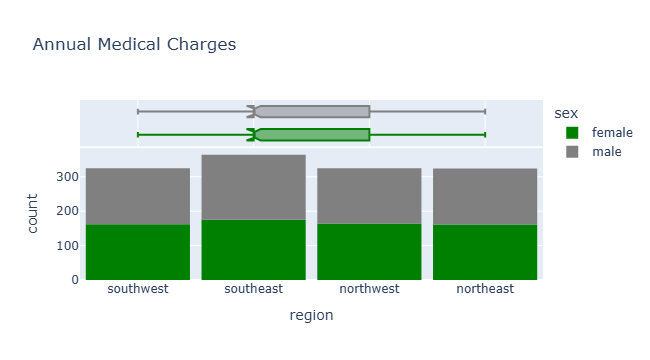

In [17]:
fig = px.histogram(medical_df,
                   x='region',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence = ['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [18]:
 medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

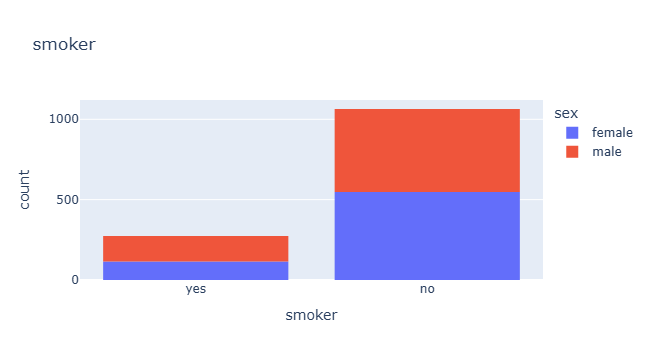

In [19]:
 px.histogram(medical_df, x='smoker', color='sex', title='smoker')

It apears that 20% of customers have reported that they smoke. Can you verify whether this matches the national average, assuming the data was collected in 2010? we can also see that smoking appears a more common habit among males. Can you verify this?

## Age and Charges

Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

In [20]:
fig = px.scatterr(medical_df,
                  x = 'age',
                  y='charges',
                  color='smoker',
                  opacity=0.8,
                  hover_data=['sex'],
                  title='Age vs. Charges')
fig.update_traces(marker_size = 5)
fig.show()

AttributeError: module 'plotly.express' has no attribute 'scatterr'